In [1]:
import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

---
## Load Data for Prior

In [2]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]

---
## Load Survey Data

In [3]:
survey_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="GE", parse_dates=["end_date"])

In [4]:
for col in ["Ciattarelli", "Sherrill", "Neither", "Undecided"]:
    survey_df[col + " Lower"] = survey_df[col] - survey_df["moe"]
    survey_df[col + " Lower"] = survey_df[col + " Lower"].apply(lambda x : 0 if x < 0 else x)
    survey_df[col + " Upper"] = survey_df[col] + survey_df["moe"]

In [5]:
survey_df["Sherrill 2P Lower"] = survey_df["Sherrill Lower"] / (survey_df["Ciattarelli Lower"] + survey_df["Sherrill Lower"])
survey_df["Sherrill 2P Upper"] = survey_df["Sherrill Upper"] / (survey_df["Ciattarelli Upper"] + survey_df["Sherrill Upper"])
survey_df["Sherrill 2P"] = survey_df["Sherrill 2P"] / 100

In [6]:
survey_df["Sample Size 2P Lower"] = (
    survey_df["sample_size"] - 
    ((survey_df["Neither Lower"] / 100) * survey_df["sample_size"]) -
    ((survey_df["Undecided Lower"] / 100) * survey_df["sample_size"])).round(0)

In [7]:
survey_df["Sample Size 2P Upper"] = (
    survey_df["sample_size"] - 
    ((survey_df["Neither Upper"] / 100) * survey_df["sample_size"]) -
    ((survey_df["Undecided Upper"] / 100) * survey_df["sample_size"])).round(0)

In [8]:
survey_df["Sherrill 2P Votes"] = (survey_df["Sherrill 2P"] * survey_df["Sample Size 2P"]).round(0)
survey_df["Sherrill 2P Votes Lower"] = (survey_df["Sherrill 2P Lower"] * survey_df["Sample Size 2P Lower"]).round(0)
survey_df["Sherrill 2P Votes Upper"] = (survey_df["Sherrill 2P Upper"] * survey_df["Sample Size 2P Upper"]).round(0)

In [40]:
id_cols = ["pollster", "end_date", "population", "mode", "moe", "Sample Size 2P"]

temp = survey_df.melt(id_vars=id_cols,
                      value_vars=["Sherrill 2P Votes", "Sherrill 2P Votes Lower", "Sherrill 2P Votes Upper"],
                      value_name="Votes")
temp["variable"] = temp["variable"].str.replace("Sherrill 2P Votes", "Survey")

temp2 = survey_df.melt(id_vars=id_cols,
                       value_vars=["Sherrill 2P", "Sherrill 2P Lower", "Sherrill 2P Upper"],
                       value_name="%")
temp2["variable"] = temp2["variable"].str.replace("Sherrill 2P", "Survey")

survey_votes_df = temp.merge(temp2, on=id_cols + ["variable"])

survey_votes_df["moe"] = survey_votes_df["moe"] / 100

survey_votes_df

,pollster,end_date,population,mode,moe,Sample Size 2P,variable,Votes,%
0,Rutgers-Eagleton,2025-06-16,rv,panel,0.052,473,Survey,294.0,0.621951
1,Rutgers-Eagleton,2025-06-16,rv,panel,0.052,473,Survey Lower,340.0,0.639665
2,Rutgers-Eagleton,2025-06-16,rv,panel,0.052,473,Survey Upper,251.0,0.608225


---
## Fit this State-Level "Model" For Now Because We Only Have One Survey So Far

In [10]:
state_past_vote = past_vote_df[
    ["Total Votes Gov 2021 2P", "Murphy Votes", "RV 2021", "Total Votes GE 2024 2P", "Harris Votes", "RV 2024", "Current RV"]].sum()

In [11]:
state_past_vote["% 2P Turnout 2021"] = state_past_vote["Total Votes Gov 2021 2P"] / state_past_vote["RV 2021"]
state_past_vote["% 2P Turnout 2024"] = state_past_vote["Total Votes GE 2024 2P"] / state_past_vote["RV 2024"]

In [12]:
state_past_vote["% Murphy 2P"] = state_past_vote["Murphy Votes"] / state_past_vote["Total Votes Gov 2021 2P"]
state_past_vote["% Harris 2P"] = state_past_vote["Harris Votes"] / state_past_vote["Total Votes GE 2024 2P"]

In [13]:
state_past_vote.round(3)

Total Votes Gov 2021 2P    2594656.000
Murphy Votes               1339471.000
RV 2021                    6575904.000
Total Votes GE 2024 2P     4188928.000
Harris Votes               2220713.000
RV 2024                    6729969.000
Current RV                 6574692.000
% 2P Turnout 2021                0.395
% 2P Turnout 2024                0.622
% Murphy 2P                      0.516
% Harris 2P                      0.530
dtype: float64

In [77]:
with pm.Model() as state_model:
    # prior
    prior_pct_D = pm.Beta("prior_pct_D",
                          mu=state_past_vote[["% Murphy 2P", "% Harris 2P"]].mean(),
                          sigma=state_past_vote[["% Murphy 2P", "% Harris 2P"]].std(ddof=1))

    # poll results, two-party
    poll_pct_D = pm.Beta("poll_pct_D", mu=survey_votes_df["%"].mean(), sigma=survey_votes_df["moe"].mean())

    beta0 = pm.Normal("beta0", mu=0, sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    pct_D = beta0 + (beta1 * prior_pct_D) + (beta2 * poll_pct_D)
    # pct_D = pm.math.invlogit(beta0 + prior_pct_D + poll_pct_D) # produces REALLY high estimates
    
    # likelihood
    y_hat = pm.Binomial(
        "y_hat",
        p=pct_D,
        n=survey_votes_df["Sample Size 2P"],
        observed=survey_votes_df["Votes"]
    )

In [78]:
with state_model:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [prior_pct_D, poll_pct_D, beta0, beta1, beta2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


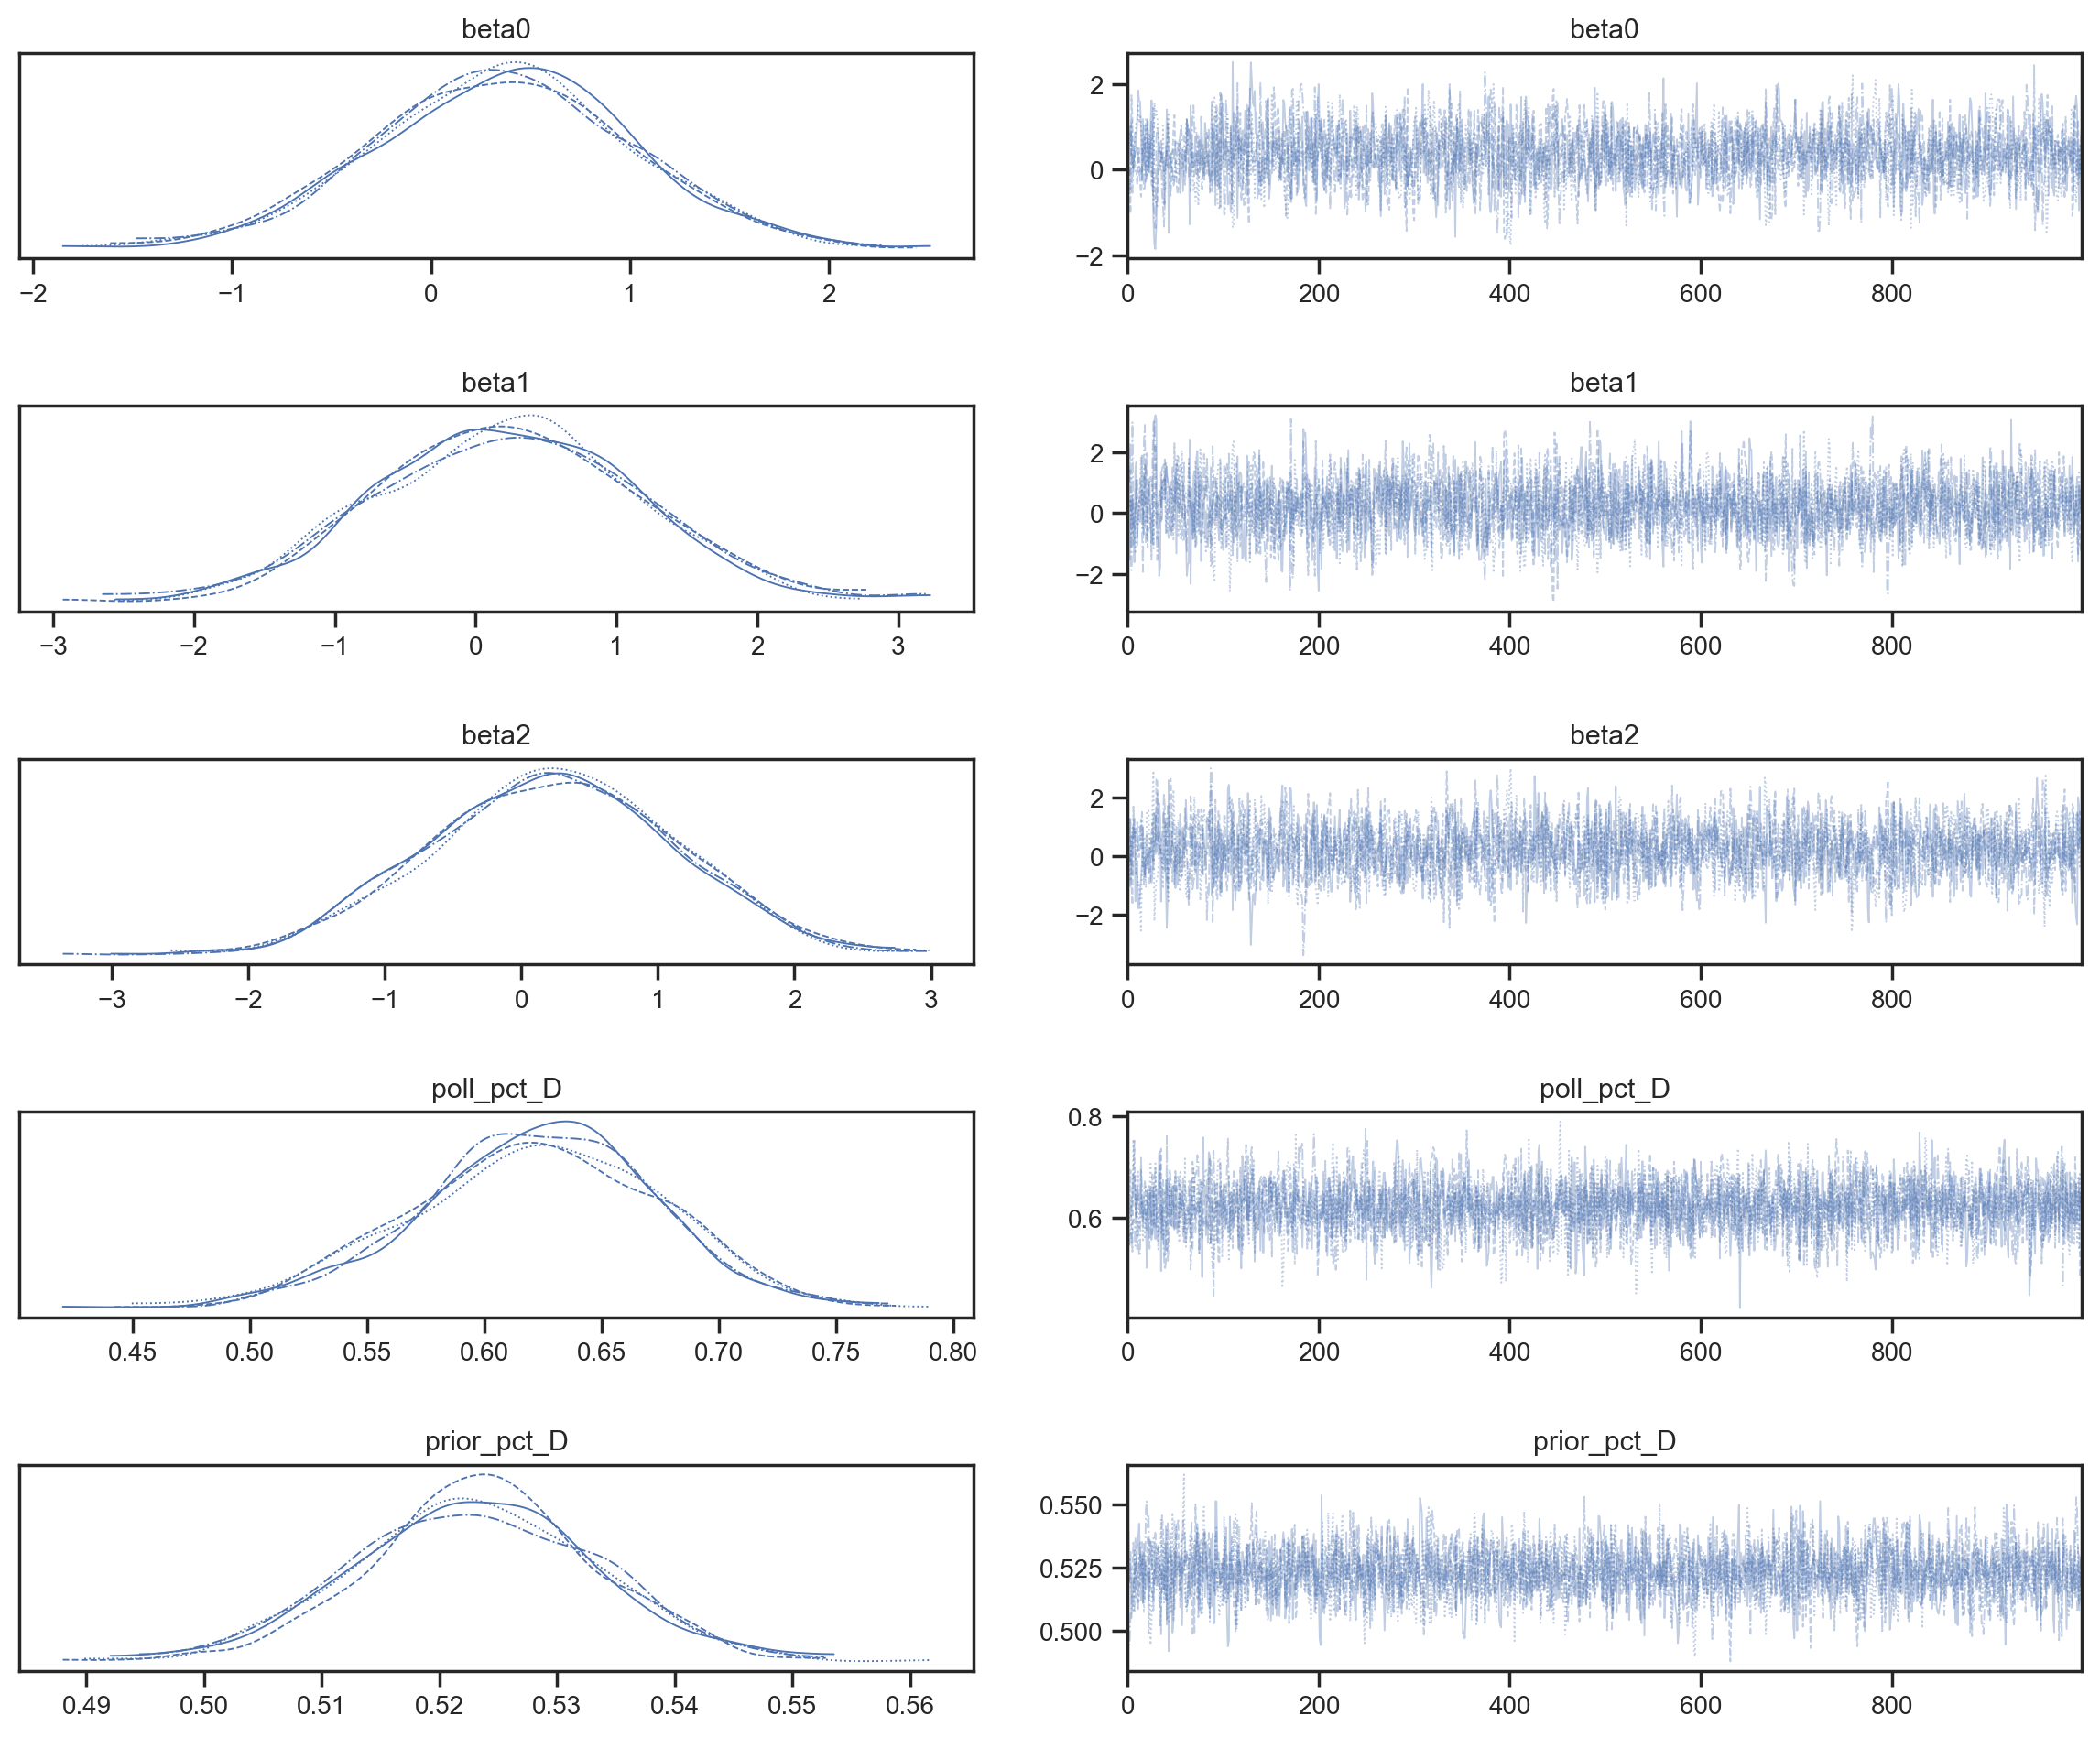

In [79]:
az.plot_trace(idata);
plt.tight_layout()

In [80]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.359,0.644,-0.778,1.654,0.014,0.011,2186.0,2289.0,1.0
beta1,0.231,0.923,-1.541,1.869,0.018,0.015,2650.0,2495.0,1.0
beta2,0.232,0.890,-1.406,1.872,0.018,0.015,2333.0,2181.0,1.0
poll_pct_D,0.622,0.051,0.527,0.718,0.001,0.001,3201.0,2540.0,1.0
prior_pct_D,0.523,0.010,0.505,0.542,0.000,0.000,3315.0,2774.0,1.0


In [81]:
with state_model:
    pred_oos_state = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [82]:
pred_oos_state["predictions"]["y_hat"].mean() / 473

<xarray.DataArray 'y_hat' ()> Size: 8B
array(0.62381413)

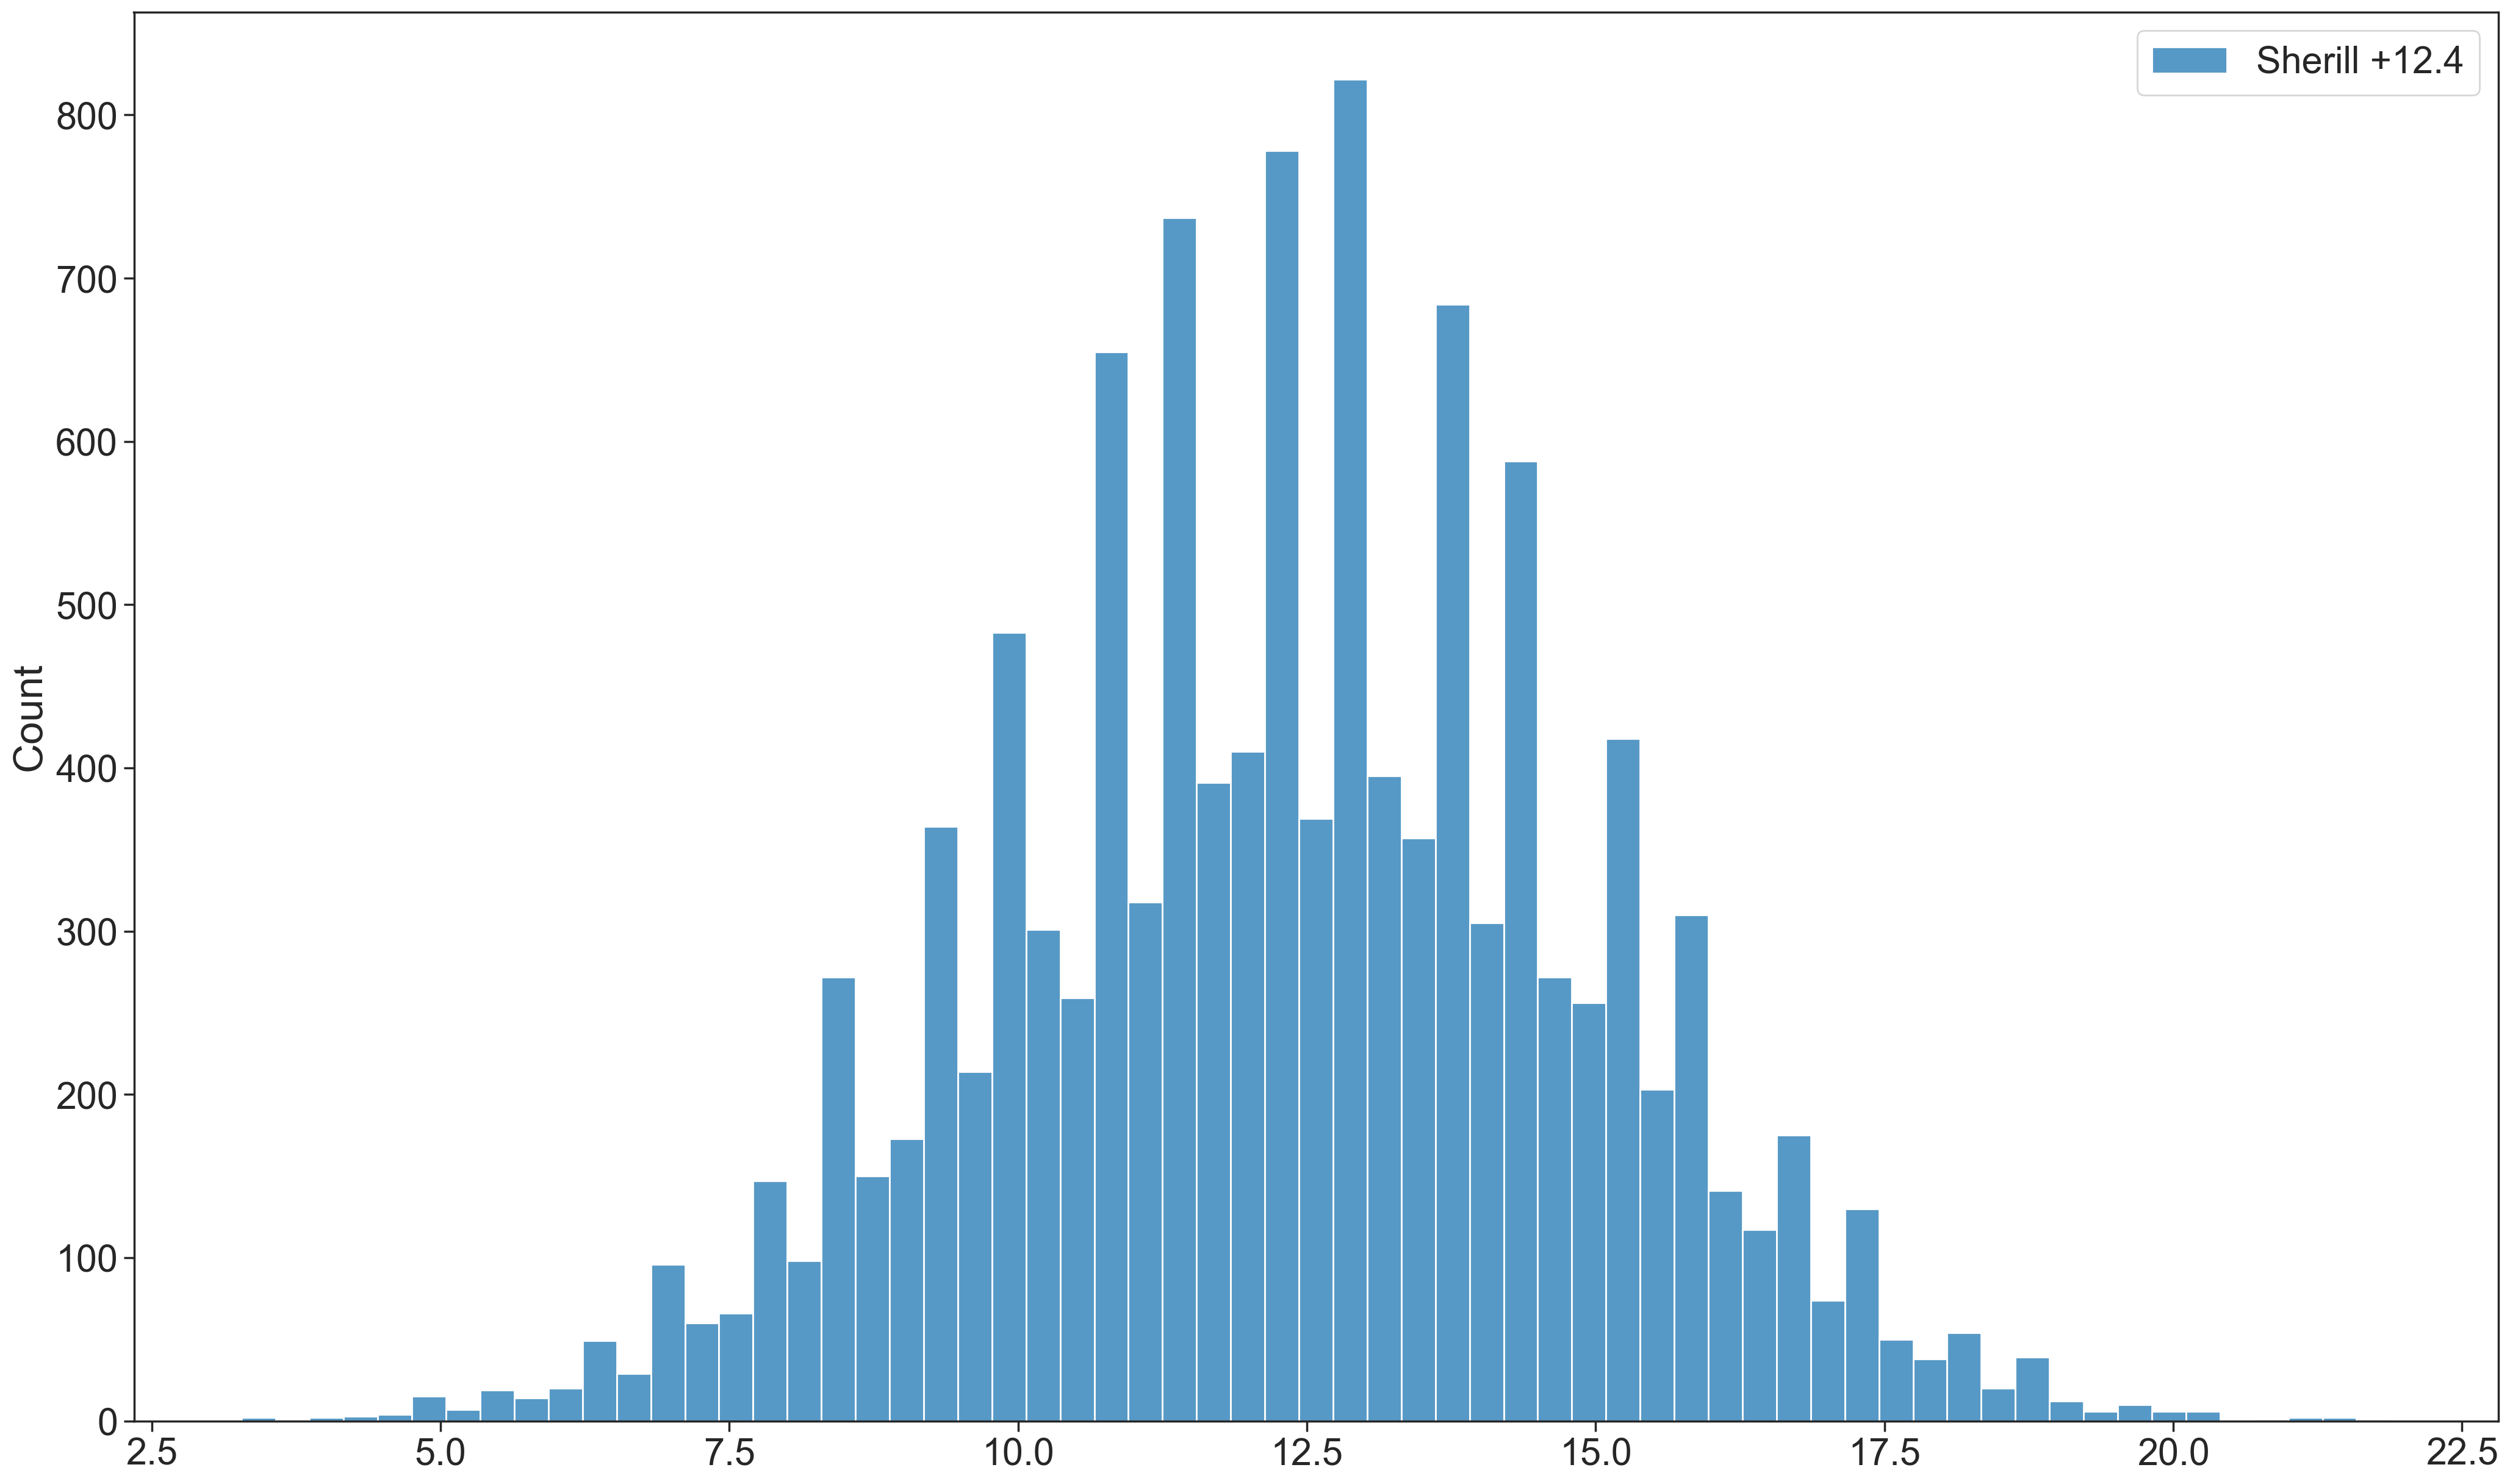

In [91]:
pred_pct_D = (pred_oos_state["predictions"]["y_hat"] / 473).stack(sample=("chain", "draw", "y_hat_dim_0")).values
pred_pct_D = (pred_pct_D - 0.5) * 100
ax = sns.histplot(x=pred_pct_D, color="tab:blue", label=f"Sherill +{np.round(pred_pct_D.mean(), 1)}")
ax.legend()
plt.show()

---

In [4]:
coords = {
    "county" : past_vote_df["County"]
}

In [5]:
with pm.Model(coords=coords) as model:
    turnout_pct = pm.Beta("turnout_pct",
                          mu=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1),
                          sigma=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].std(ddof=1, axis=1),
                          dims="county")

    turnout = pm.Binomial("turnout",
                          p=turnout_pct,
                          n=past_vote_df["Current RV"],
                          dims="county")

    prior_pct_D = pm.Beta("prior_pct_D",
                          mu=past_vote_df[["% Murphy 2P", "% Harris 2P"]].mean(axis=1),
                          sigma=past_vote_df[["% Murphy 2P", "% Harris 2P"]].std(ddof=1, axis=1),
                          dims="county")

    # prior_vote_D = pm.Deterministic("prior_vote_D", turnout * prior_pct_D, dims="county")

In [6]:
with model:
    idata = pm.sample()#extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [turnout_pct, prior_pct_D]
>Metropolis: [turnout]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


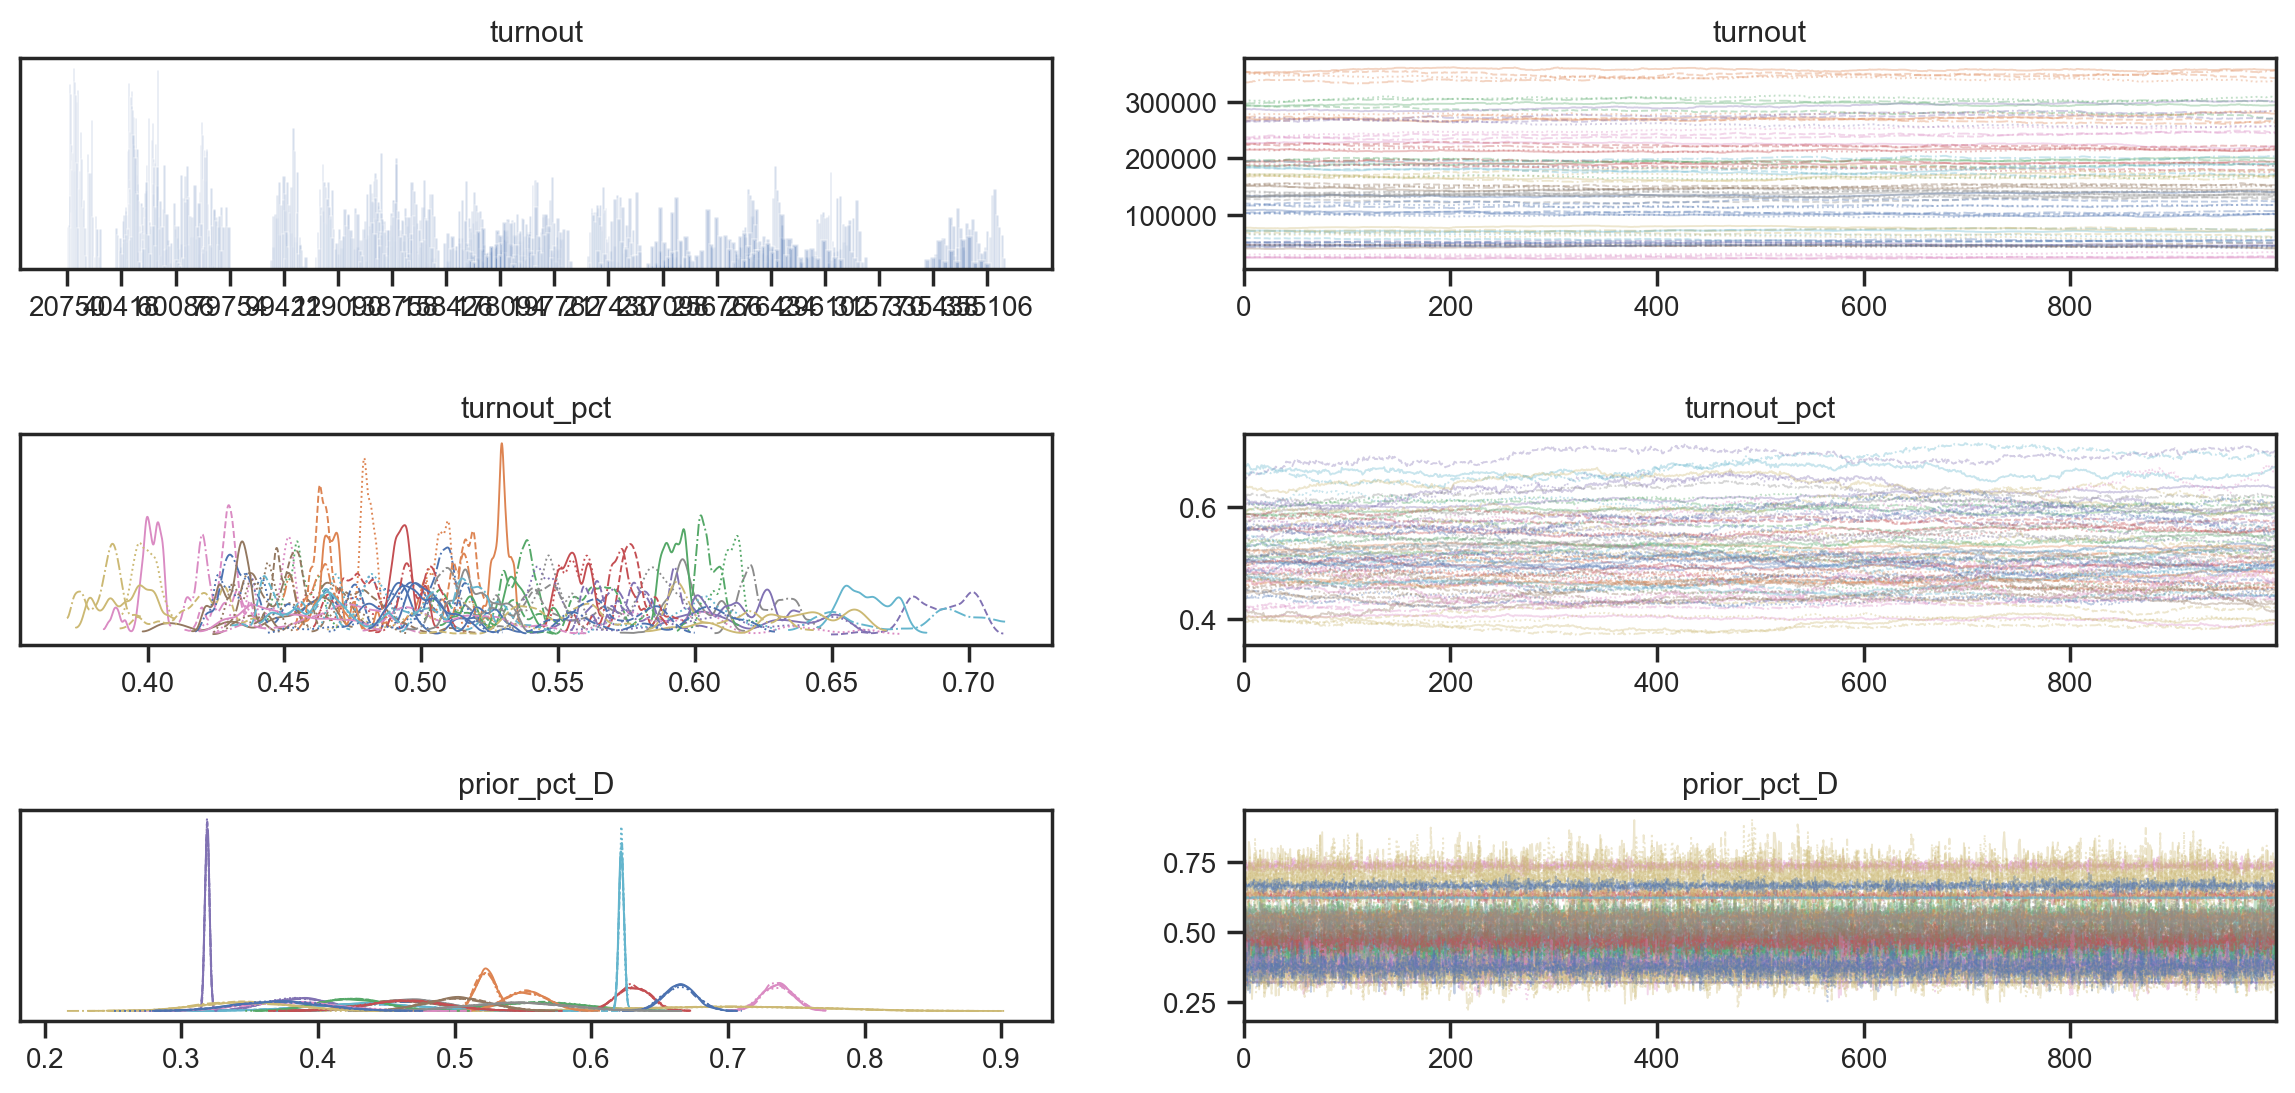

In [7]:
az.plot_trace(idata);
plt.tight_layout()

In [8]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

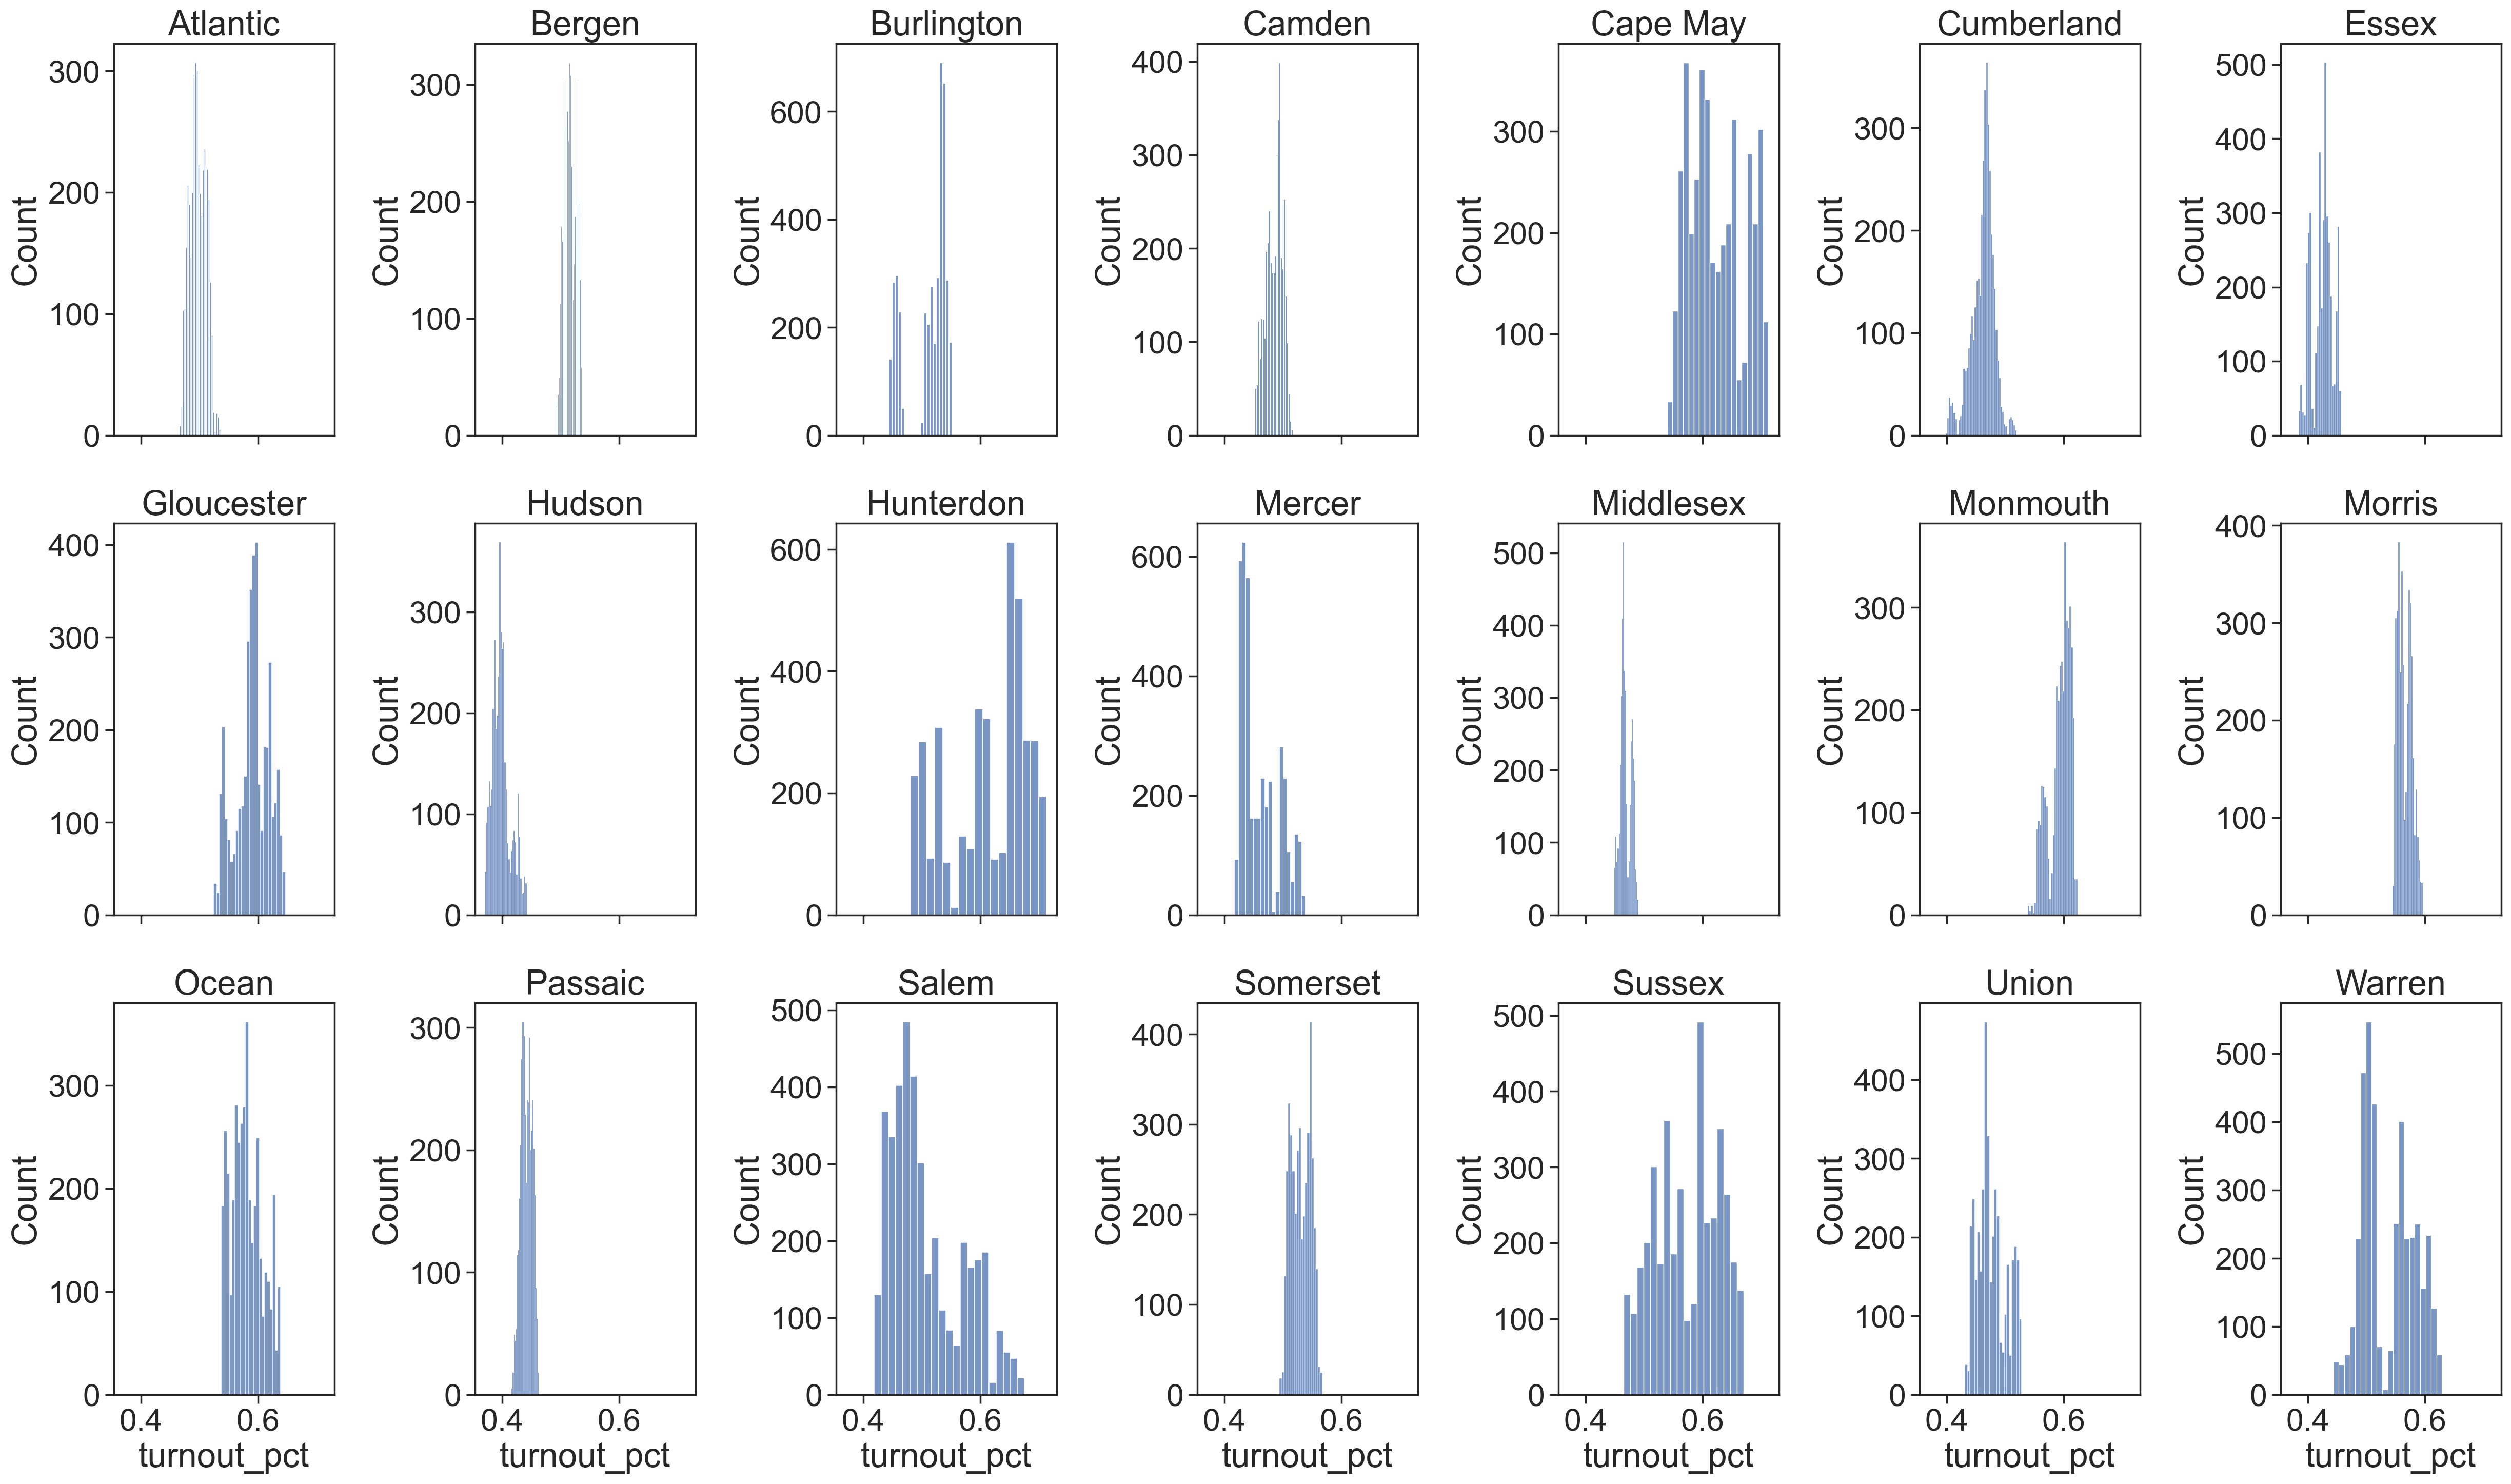

In [9]:
(fig, axs) = plt.subplots(3, 7, sharex=True, sharey=False)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["turnout_pct"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax)
    ax.set_title(str(c.values))

plt.tight_layout()

In [10]:
rows = []
for c in idata.posterior.coords["county"]:
    post = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    row = {"County" : str(c.values),
           "Pred" : np.mean(post.values).round(0),
           "Lower" : np.quantile(post.values, 0.025).round(0),
           "Upper" : np.quantile(post.values, 0.975).round(0)}
    rows.append(row)
pandas.DataFrame(rows)

,County,Pred,Lower,Upper
0,Atlantic,101041.0,96098.0,105836.0
1,Bergen,348718.0,336865.0,360435.0
2,Burlington,187170.0,163625.0,200578.0
3,Camden,187925.0,177168.0,196656.0
4,Cape May,47628.0,42292.0,53643.0
5,Cumberland,44309.0,39328.0,47530.0
6,Essex,239377.0,220044.0,255493.0
7,Gloucester,133969.0,121510.0,144708.0
8,Hudson,169666.0,159158.0,184797.0
9,Hunterdon,65168.0,52035.0,75057.0


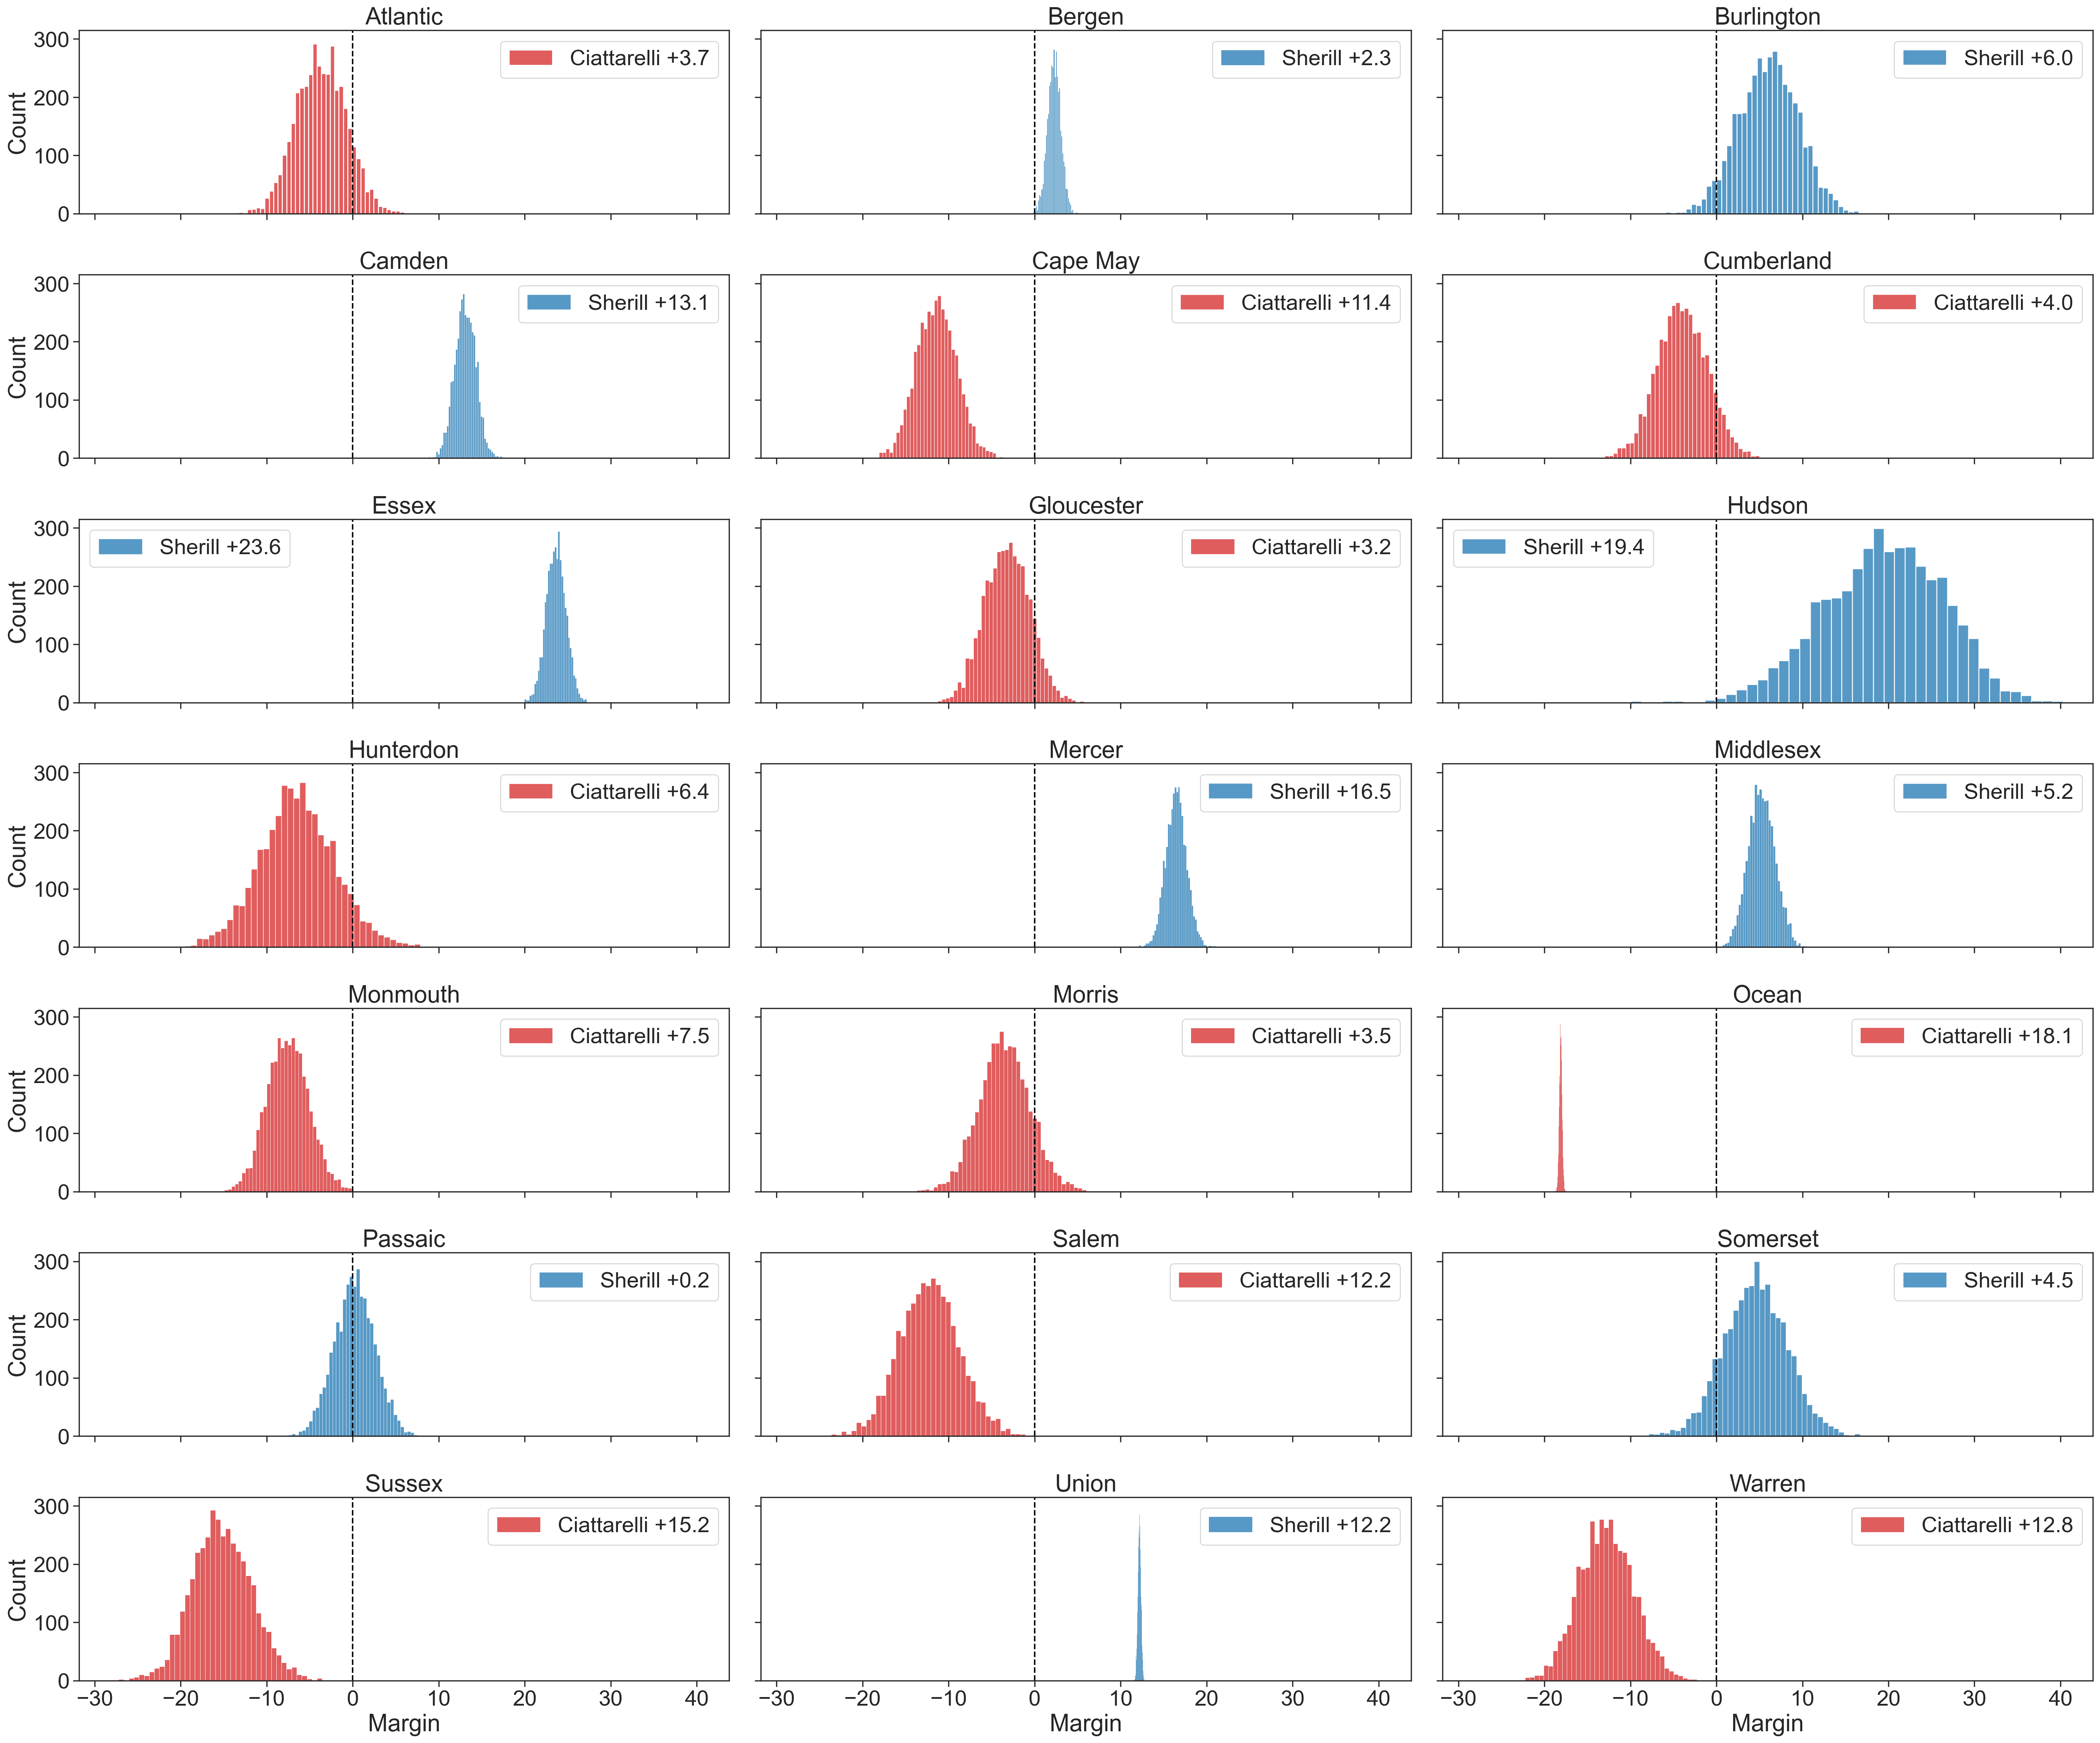

In [36]:
rows = []
(fig, axs) = plt.subplots(7, 3, sharex=True, sharey=True)
fig.set_size_inches(30, 25)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    margin = (post - 0.5) * 100
    row = {"County" : str(c.values),
           "Pred" : np.mean(margin.values),
           "Lower" : np.quantile(margin.values, 0.025),
           "Upper" : np.quantile(margin.values, 0.975)}
    rows.append(row)
    mean_margin = np.mean(margin.values).mean()

    if mean_margin > 0:
        sns.histplot(x=margin, ax=ax, color="tab:blue", label=f"Sherill +{np.round(mean_margin, 1)}")
    else:
        sns.histplot(x=margin, ax=ax, color="tab:red", label=f"Ciattarelli +{np.round(mean_margin, 1) * -1}")
    
    ax.set_title(str(c.values))
    ax.set_xlabel("Margin")
    ax.legend()
    ax.axvline(0, linestyle="--", color="black")

plt.tight_layout()

In [12]:
pandas.DataFrame(rows).round(1)

,County,Pred,Lower,Upper
0,Atlantic,-3.7,-9.3,2.0
1,Bergen,2.3,0.7,3.8
2,Burlington,6.0,-0.7,12.7
3,Camden,13.1,10.7,15.4
4,Cape May,-11.4,-15.8,-6.9
5,Cumberland,-4.0,-9.6,1.6
6,Essex,23.6,21.4,25.9
7,Gloucester,-3.2,-8.2,1.9
8,Hudson,19.4,5.4,31.8
9,Hunterdon,-6.4,-14.9,2.4


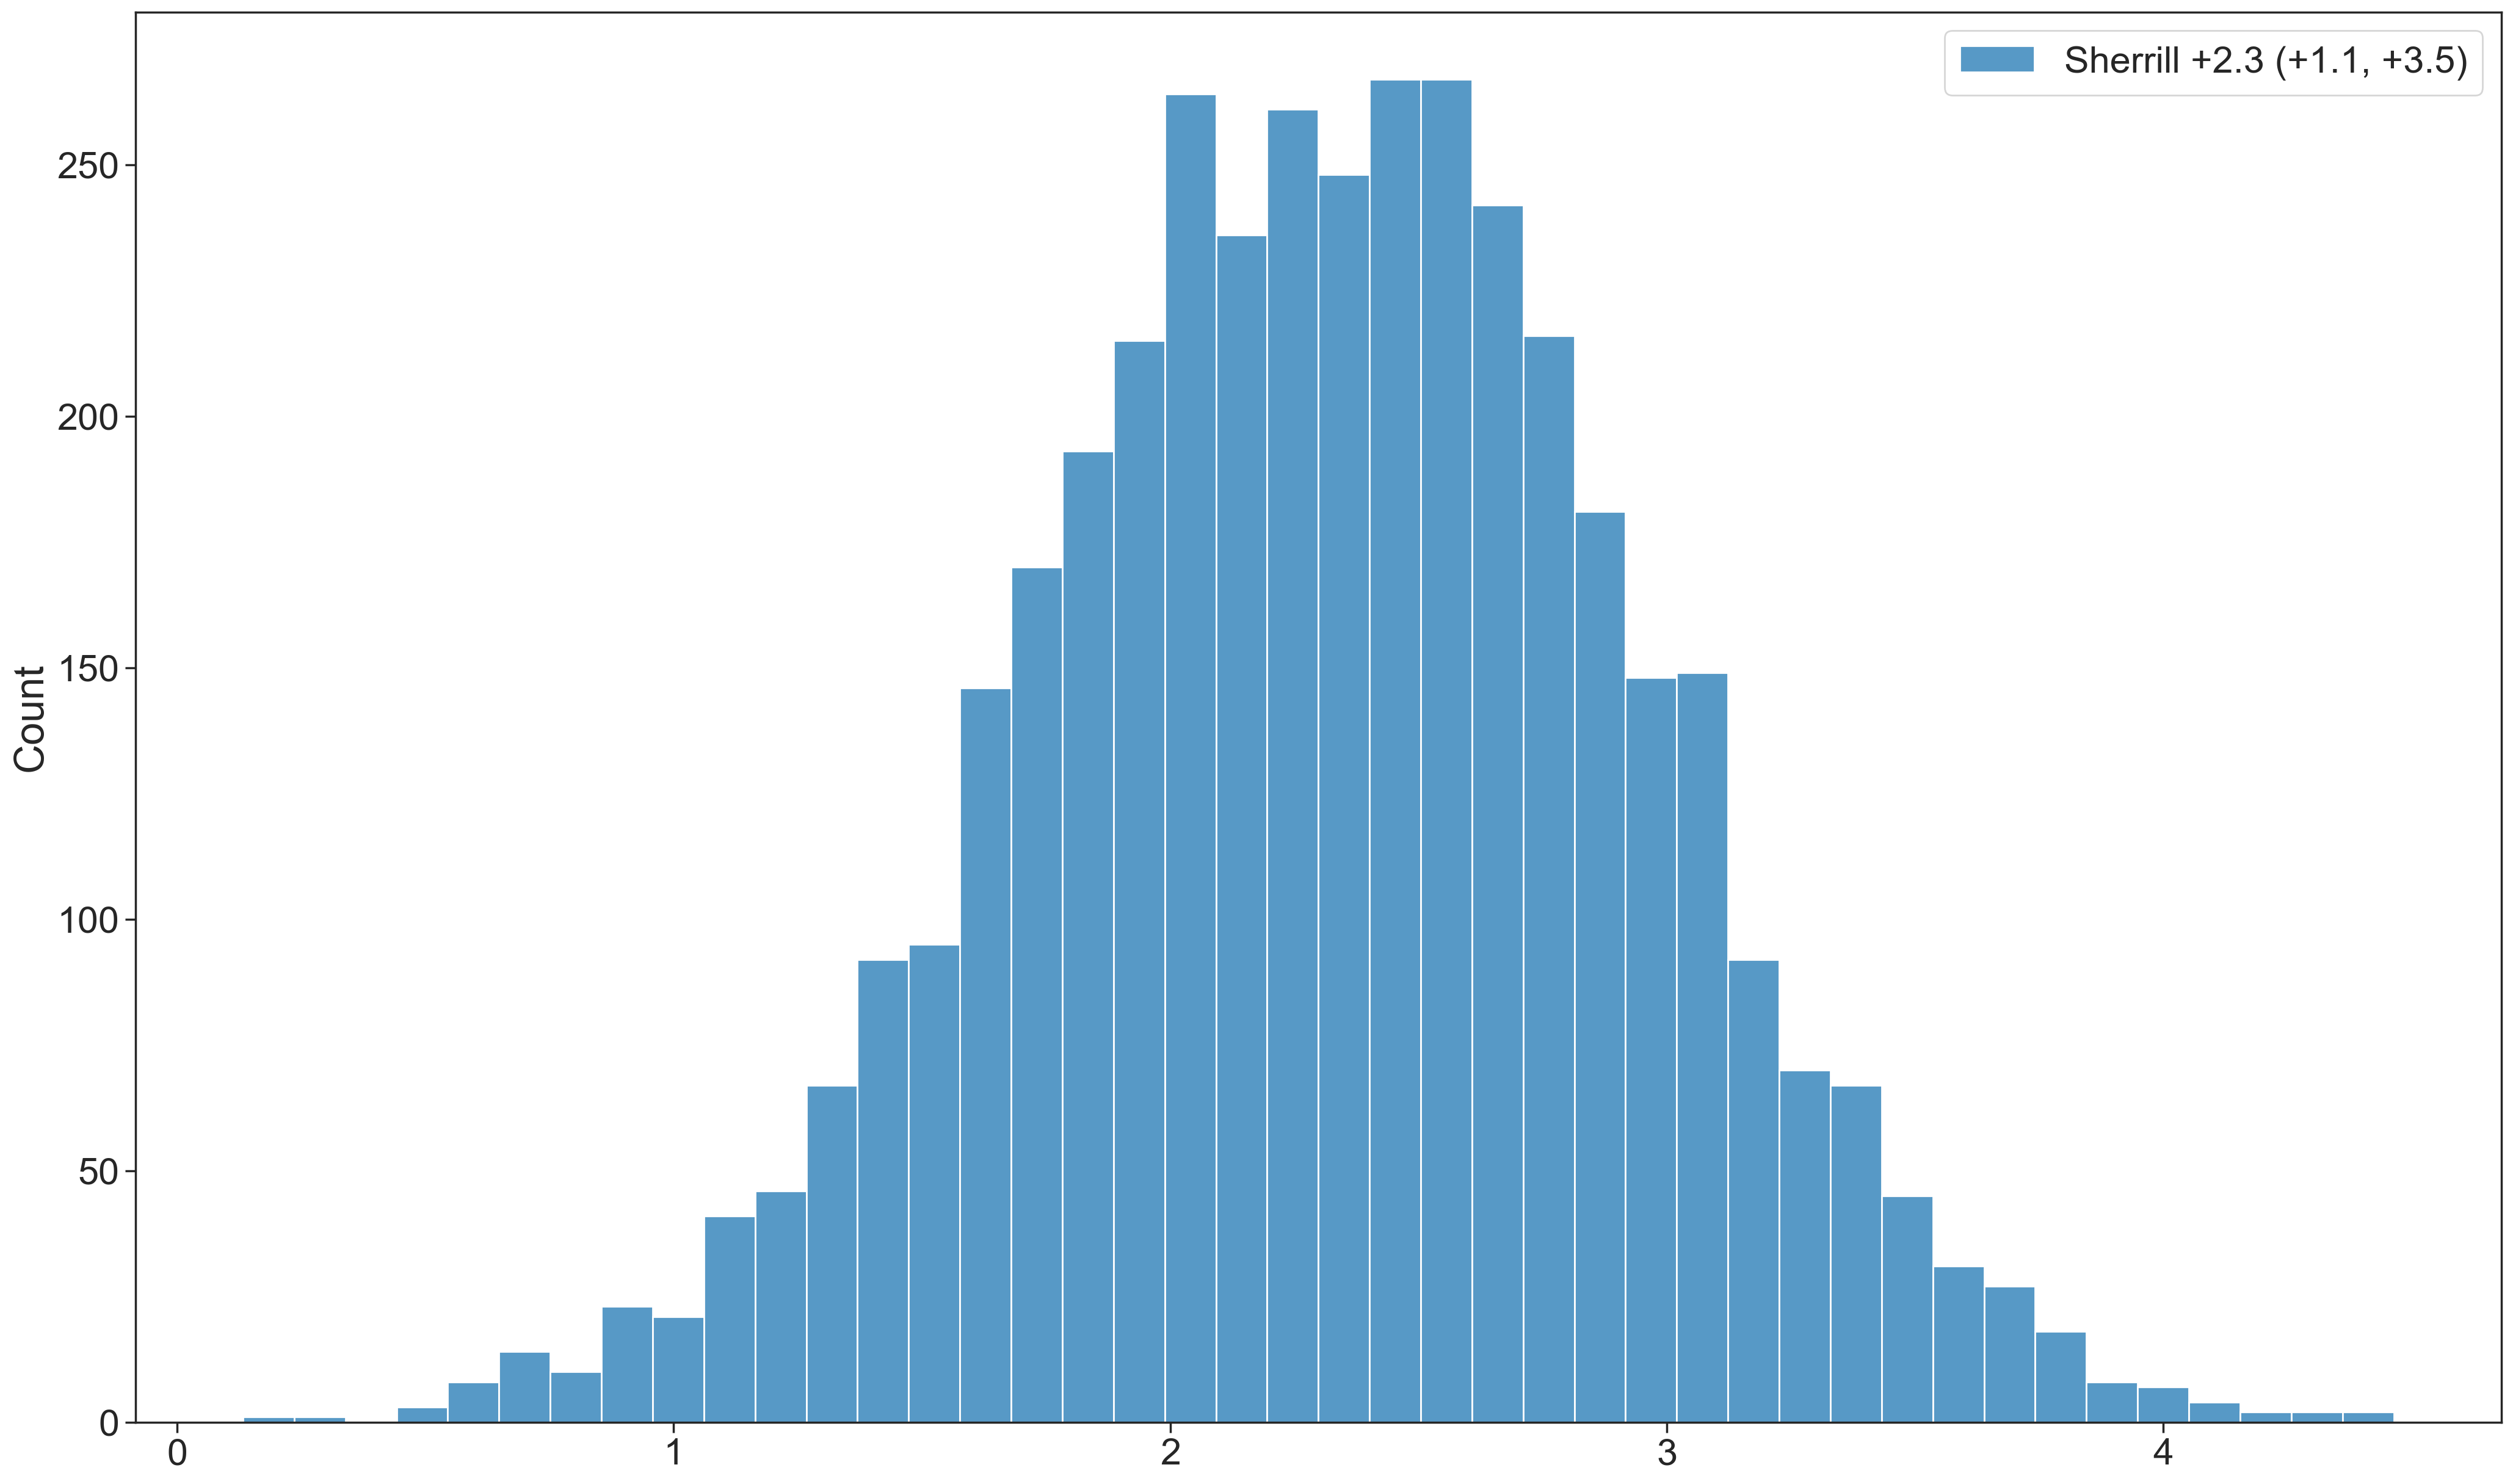

In [43]:
state_turnout = None
state_votes_D = None

for c in idata.posterior.coords["county"]:
    post_turnout = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    post_pct_D = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    votes_D = post_pct_D * post_turnout
    if state_turnout is None and state_votes_D is None:
        state_turnout = post_turnout.values
        state_votes_D = votes_D.values
    else:
        state_turnout = state_turnout + post_turnout.values
        state_votes_D = state_votes_D + votes_D.values

state_pct_D = state_votes_D / state_turnout
state_margin = (state_pct_D - 0.5) * 100
state_margin_lower = np.quantile(state_margin, 0.025)
state_margin_upper = np.quantile(state_margin, 0.975)

label = f"Sherrill +{state_margin.mean().round(1)} (+{state_margin_lower.round(1)}, +{state_margin_upper.round(1)})"

ax = sns.histplot(x=state_margin, label=label, color="tab:blue")
# ax.axvline(state_margin_lower, linestyle="--", color="black", label=f"Lower ")
# ax.axvline(state_margin_upper, linestyle="--", color="black", label=f"Upper ")
ax.legend()
plt.show()